In [382]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [383]:
df = pd.read_csv('data/chart.csv', sep=';')

In [384]:
df["DateTime"] = pd.to_datetime(df["DateTime"], format="%Y-%m-%d %H:%M:%S")

In [385]:
# Resample df by 30 minutes intervals
# df = df.set_index("DateTime").resample("1h").sum().reset_index()

In [386]:
df["date"] = df["DateTime"].dt.date
df["hour"] = df["DateTime"].dt.time

In [387]:
df.head()

,DateTime,Energy,date,hour
0,2023-01-01 00:00:00,0.010,2023-01-01,00:00:00
1,2023-01-01 00:15:00,0.004,2023-01-01,00:15:00
2,2023-01-01 00:30:00,0.008,2023-01-01,00:30:00
3,2023-01-01 00:45:00,0.019,2023-01-01,00:45:00
4,2023-01-01 01:00:00,0.004,2023-01-01,01:00:00


In [388]:
df.describe()

,DateTime,Energy
count,107880,107880.000000
mean,2024-07-15 23:53:29.265851136,0.026685
min,2023-01-01 00:00:00,0.000000
25%,2023-10-08 23:26:15,0.007000
50%,2024-07-15 23:52:30,0.013000
75%,2025-04-23 00:18:45,0.021000
max,2026-01-28 23:45:00,1.334000
std,NaN,0.063903


In [389]:
# Group by date and hour to calculate average values
grouped = df.groupby(['date', 'hour']).mean().reset_index()

# Remove DateTime column if exists
if 'DateTime' in grouped.columns:
    grouped = grouped.drop(columns=['DateTime'])

grouped.head()

,date,hour,Energy
0,2023-01-01,00:00:00,0.010
1,2023-01-01,00:15:00,0.004
2,2023-01-01,00:30:00,0.008
3,2023-01-01,00:45:00,0.019
4,2023-01-01,01:00:00,0.004


In [390]:
grouped["Energy_Wh"] = grouped["Energy"] * 1000 # Since Energy is in kWh
grouped.head()

,date,hour,Energy,Energy_Wh
0,2023-01-01,00:00:00,0.010,10.0
1,2023-01-01,00:15:00,0.004,4.0
2,2023-01-01,00:30:00,0.008,8.0
3,2023-01-01,00:45:00,0.019,19.0
4,2023-01-01,01:00:00,0.004,4.0


In [391]:
grouped.describe()

,Energy,Energy_Wh
count,107880.000000,107880.000000
mean,0.026685,26.684881
std,0.063903,63.903443
min,0.000000,0.000000
25%,0.007000,7.000000
50%,0.013000,13.000000
75%,0.021000,21.000000
max,1.334000,1334.000000


In [392]:
# Get 5% and 95% percentiles
p5 = np.percentile(grouped["Energy_Wh"], 5)
p95 = np.percentile(grouped["Energy_Wh"], 99)

display(p5, p95)

np.float64(4.0)

np.float64(363.0)

In [393]:
# Where energy_Wh is = small, set it to 7 (25%)
grouped.loc[grouped["Energy_Wh"] < 7, "Energy_Wh"] = 7

# Where energy_Wh is > 81, set it to 81 (95%)
grouped.loc[grouped["Energy_Wh"] > 363, "Energy_Wh"] = 363

grouped.head()

,date,hour,Energy,Energy_Wh
0,2023-01-01,00:00:00,0.010,10.0
1,2023-01-01,00:15:00,0.004,7.0
2,2023-01-01,00:30:00,0.008,8.0
3,2023-01-01,00:45:00,0.019,19.0
4,2023-01-01,01:00:00,0.004,7.0


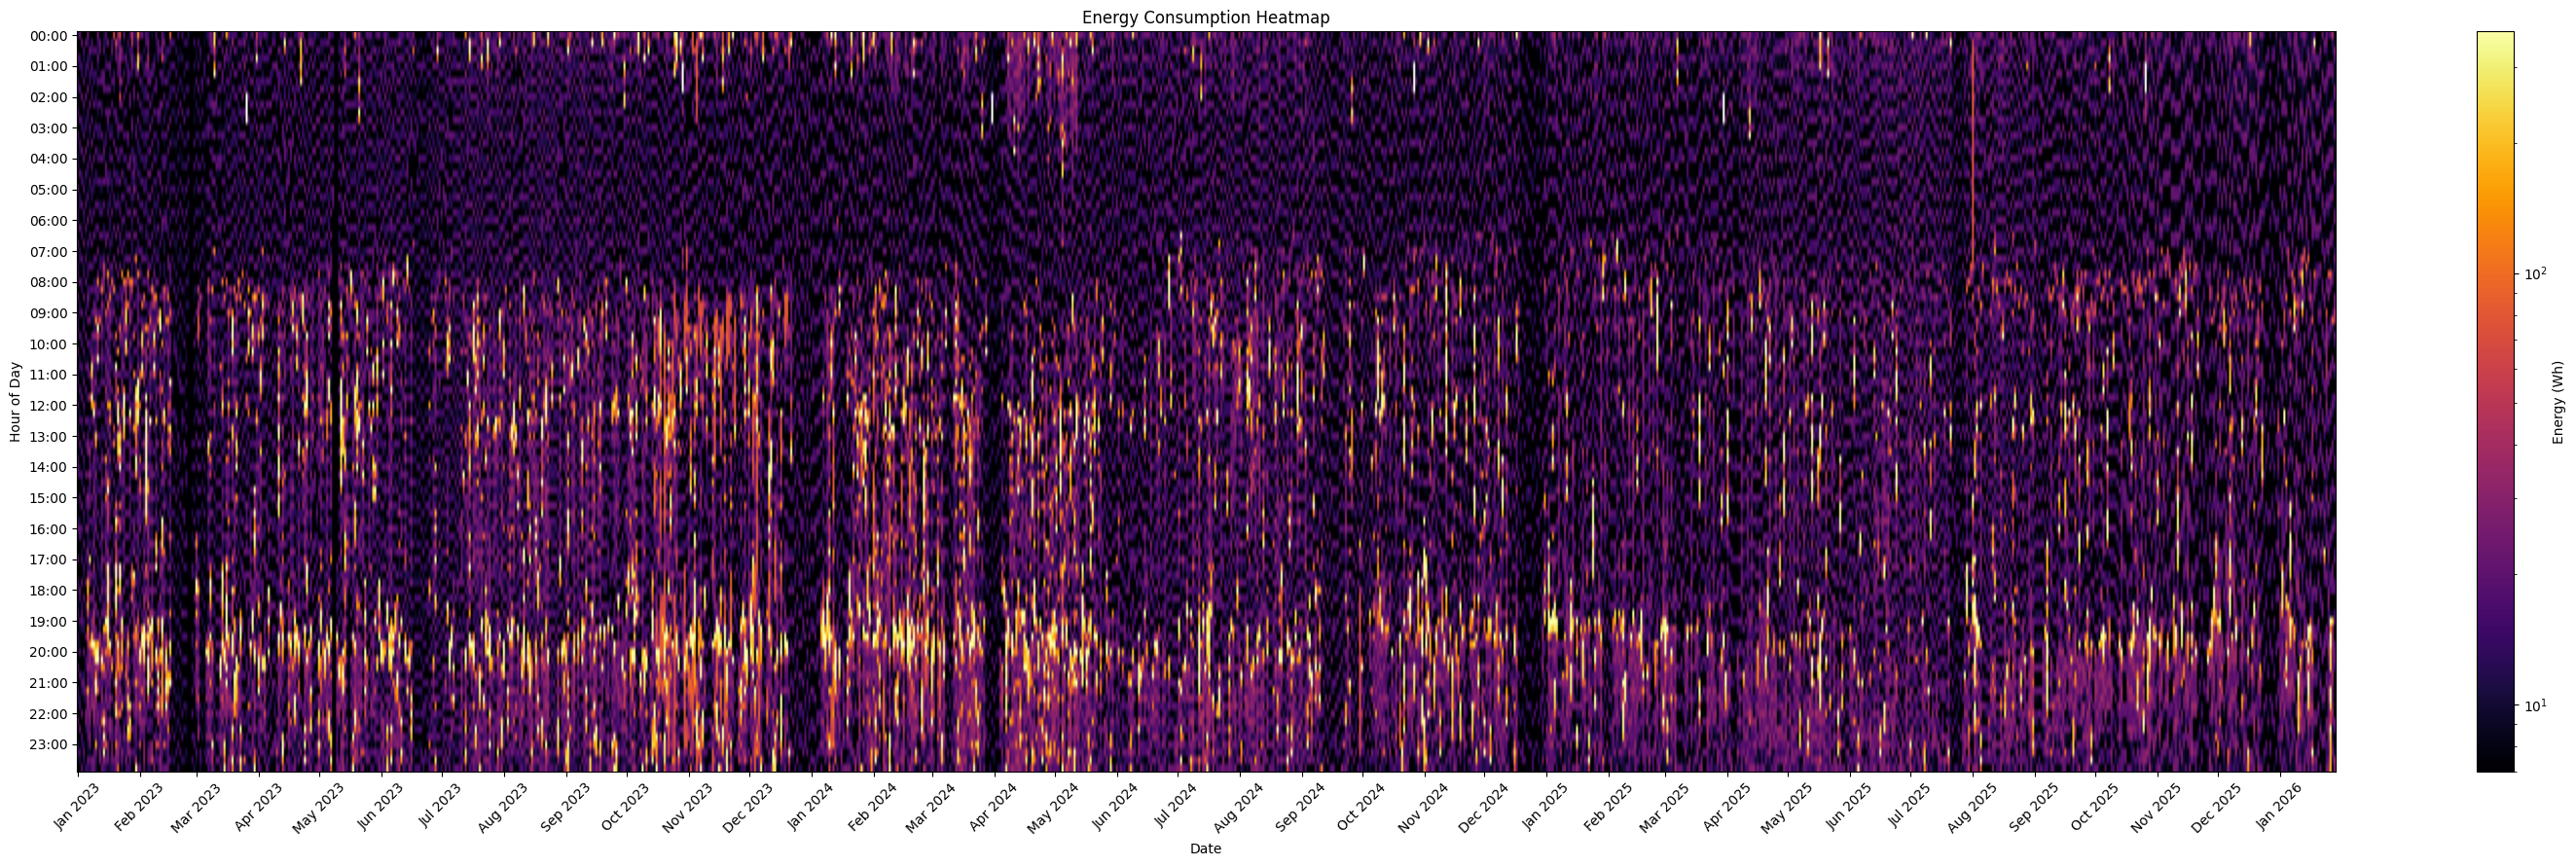

In [381]:
from matplotlib.colors import LogNorm

# Plot as a heatmap (x axis = date, y axis = hour, color = Energy_Wh)
pivot_table = grouped.pivot(index='hour', columns='date', values='Energy_Wh')
plt.figure(figsize=(30, 9))
plt.imshow(pivot_table, aspect='auto', cmap='inferno', origin='upper', norm=LogNorm())
plt.colorbar(label='Energy (Wh)')
plt.xlabel('Date')
plt.ylabel('Hour of Day')
plt.title('Energy Consumption Heatmap')
# Create monthly tick labels - one per month
dates = pd.to_datetime(pivot_table.columns)
# Get first occurrence of each month
month_indices = []
month_labels = []
for i, date in enumerate(dates):
    if i == 0 or date.month != dates[i-1].month:
        month_indices.append(i)
        month_labels.append(date.strftime('%b %Y'))

plt.xticks(ticks=month_indices, labels=month_labels, rotation=45)
# Show only full hours (every 4th row since data is in 15-minute intervals)
# Calculate intervals per hour based on pivot table rows
intervals_per_hour = len(pivot_table) // 24
hour_indices = range(0, len(pivot_table), intervals_per_hour)
hour_labels = [f"{h:02d}:00" for h in range(24)]
plt.yticks(ticks=hour_indices, labels=hour_labels)
plt.tight_layout()
plt.show()

In [395]:
grouped.head()

,date,hour,Energy,Energy_Wh
0,2023-01-01,00:00:00,0.010,10.0
1,2023-01-01,00:15:00,0.004,7.0
2,2023-01-01,00:30:00,0.008,8.0
3,2023-01-01,00:45:00,0.019,19.0
4,2023-01-01,01:00:00,0.004,7.0


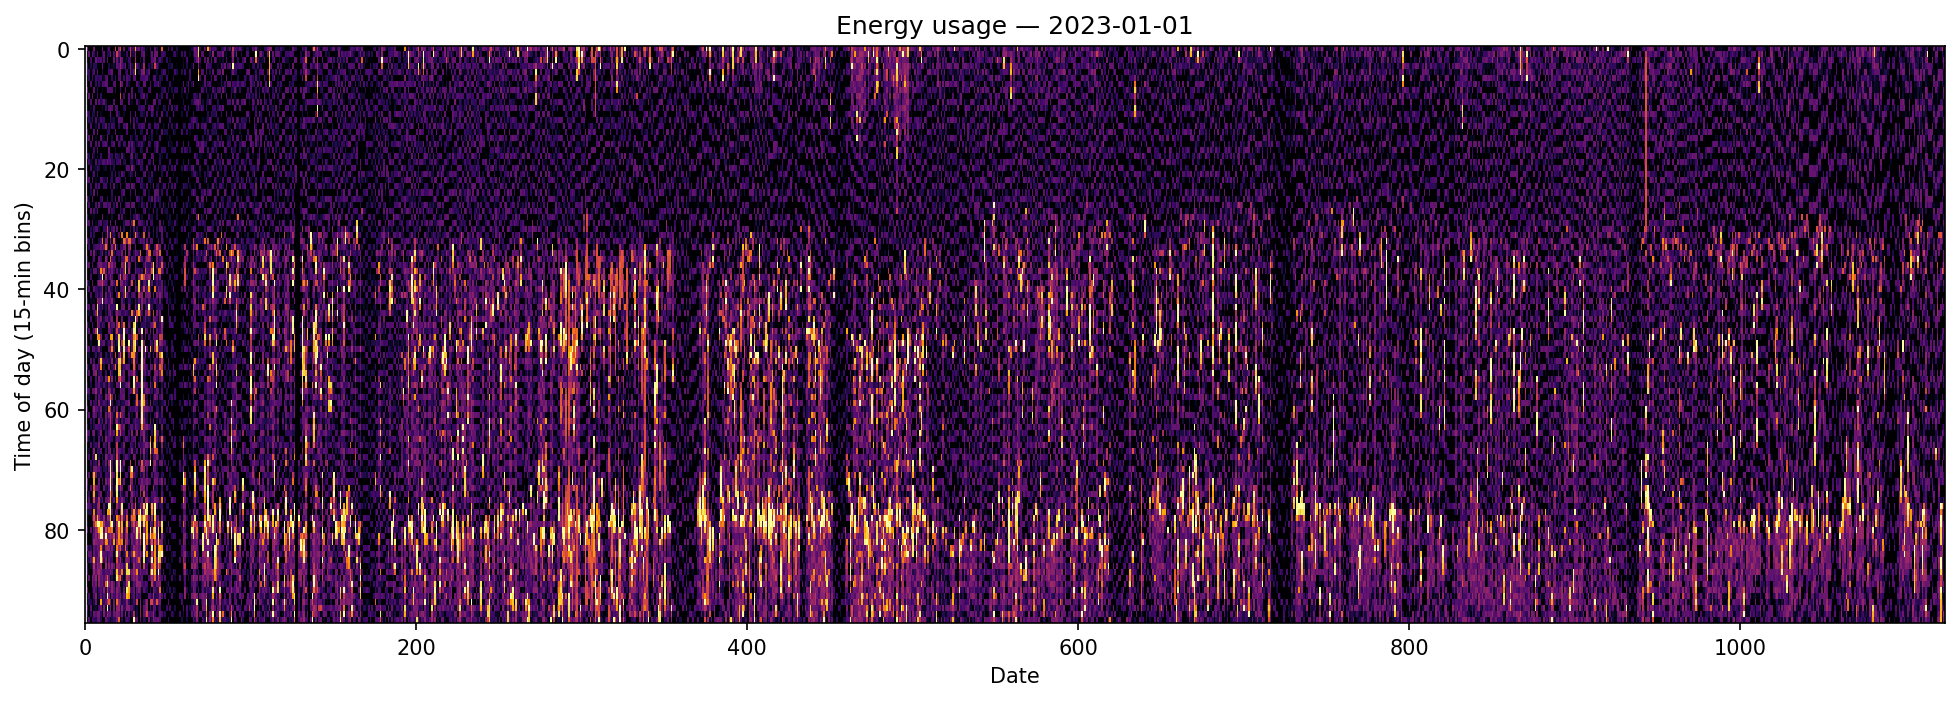

In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML

# ---------- Build pivot (15-min bins) ----------
g = grouped.copy()
g["date"] = pd.to_datetime(g["date"]).dt.normalize()

P = g.pivot(index="hour", columns="date", values="Energy_Wh").sort_index()
Z = P.to_numpy()

# log-safe
Z[~np.isfinite(Z)] = np.nan
pos = Z[np.isfinite(Z) & (Z > 0)]
eps = np.nanpercentile(pos, 1) if pos.size else 1e-6
Z = np.where((~np.isfinite(Z)) | (Z <= 0), eps, Z)

vmin = np.nanpercentile(Z, 2)
vmax = np.nanpercentile(Z, 99.7)
vmin = max(vmin, eps)

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(16, 5), dpi=150)
im = ax.imshow(
    Z, aspect="auto", origin="upper", cmap="inferno",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest"
)

ax.set_ylabel("Time of day (15-min bins)")
ax.set_xlabel("Date")
title = ax.set_title("Energy usage — daily rhythm over time")

# Cursor line
cursor = ax.axvline(0, color="white", lw=2, alpha=0.85)

# Highlight rectangle in DATA coordinates:
# x spans one column (width=1), y spans full image height
highlight = Rectangle(
    (-0.5, -0.5),   # (x, y)
    1.0,            # width
    Z.shape[0],     # height
    facecolor="white",
    alpha=0.06,
    edgecolor="none"
)
ax.add_patch(highlight)

def update(i):
    cursor.set_xdata([i, i])
    highlight.set_x(i - 0.5)
    title.set_text(f"Energy usage — {P.columns[i].date()}")
    return (cursor, highlight, im)

ani = FuncAnimation(fig, update, frames=Z.shape[1], interval=25, blit=True)

In [410]:
# MP4 (requires ffmpeg)
try:
    ani.save("energy_scan.mp4", fps=30, dpi=200)
    print("Saved energy_scan.mp4")
except Exception as e:
    print("MP4 save failed, falling back to GIF.\nError:", e)
    ani.save("energy_scan.gif", fps=20, dpi=150)
    print("Saved energy_scan.gif")


Saved energy_scan.mp4


In [ ]:
import numpy as np
import pandas as pd
import mido
from mido import Message, MidiFile, MidiTrack, MetaMessage

def sonify_sliding_memory(
    grouped: pd.DataFrame,
    out_path: str = "energy_sliding_memory.mid",
    bpm: int = 96,

    # Timeline controls
    hours_per_second: float = 3.0,   # speed of the 24-hour sweep
    hop_hours: int = 1,              # step size in hours (1 = every hour, 2 = every 2 hours)

    # "Memory" controls (days as voices)
    window_days: int = 21,           # how many recent days are in the chord at once
    keep_top_k: int = 10,            # keep only top K days in that window for the current hour
    pitch_span: int = 72,            # spread day-pitches across semitones to avoid mud (60–84 good)
    base_midi: int = 36,             # C2

    # Dynamics / cleanliness
    min_velocity: int = 6,
    max_velocity: int = 115,
    gate_velocity: int = 18,         # drop quieter notes
    note_len_beats: float = 0.35,    # duration per hour-step

    # Sound
    channel: int = 0,
    program: int = 89,               # 89 pad; try 52 choir, 0 piano, 81 lead

    # Optional "chorus shimmer": tiny time offsets per note
    humanize_ms: float = 6.0,
    seed: int = 7
):
    df = grouped.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    df = df.dropna(subset=["date", "hour", "Energy_Wh"])

    # hour -> hour_int 0..23 (supports datetime.time or strings like "00:15:00")
    def to_hour_int(x):
        if hasattr(x, "hour"):  # datetime.time
            return int(x.hour)
        # string -> timedelta -> hour
        td = pd.to_timedelta(str(x))
        return int((td.total_seconds() // 3600) % 24)

    df["hour_int"] = df["hour"].map(to_hour_int).astype(int)

    # Hourly mean energy per (date, hour)
    A = (
        df.groupby(["date", "hour_int"], as_index=False)["Energy_Wh"].mean()
          .pivot(index="date", columns="hour_int", values="Energy_Wh")
          .reindex(columns=range(24))
          .fillna(0.0)
          .sort_index()
    )

    dates = A.index.to_list()
    Ndays = len(dates)
    if Ndays < 2:
        raise ValueError("Need at least 2 days for a sliding-memory sonification.")

    E = A.to_numpy(dtype=float)  # shape (Ndays, 24)

    # Robust log-ish scaling -> velocities
    pos = E[E > 0]
    eps = np.percentile(pos, 1) if pos.size else 1e-6
    Esafe = np.where(E <= 0, eps, E)
    elog = np.log10(Esafe)

    lo, hi = np.percentile(elog, 5), np.percentile(elog, 99.5)
    En = np.clip((elog - lo) / (hi - lo + 1e-12), 0, 1)
    V = (min_velocity + En * (max_velocity - min_velocity)).astype(int)

    # MIDI setup
    ticks_per_beat = 480
    mid = MidiFile(ticks_per_beat=ticks_per_beat)
    tr = MidiTrack()
    mid.tracks.append(tr)
    tr.append(MetaMessage("set_tempo", tempo=mido.bpm2tempo(bpm), time=0))
    tr.append(Message("program_change", program=program, channel=channel, time=0))

    beats_per_hour = (bpm / 60.0) / max(hours_per_second, 1e-9)
    step_ticks = int(round(beats_per_hour * ticks_per_beat))
    note_len_ticks = int(round(note_len_beats * ticks_per_beat))

    rng = np.random.default_rng(seed)
    beats_per_sec = bpm / 60.0

    # Build event list (absolute ticks), then convert to deltas
    events = []  # (tick, type, note, vel)

    # We "play through the year" by sliding the day-window forward.
    # For each day index d_end, we render a 24-hour sweep (or every hop_hours).
    # At hour h, chord notes are chosen from the last window_days (ending at d_end).
    for d_end in range(Ndays):
        d_start = max(0, d_end - window_days + 1)
        window_idx = np.arange(d_start, d_end + 1)

        # Map window days to pitches (local mapping so harmony "moves" with time)
        # Older days lower, newer days higher
        wN = len(window_idx)
        day_pitches = np.round(
            base_midi + (np.arange(wN) / max(1, wN - 1)) * pitch_span
        ).astype(int)

        # Base time offset for this day-sweep
        # Each "day-sweep" contains 24/hop_hours steps
        steps_per_sweep = int(np.ceil(24 / hop_hours))
        sweep_start_step = d_end * steps_per_sweep

        for si, h in enumerate(range(0, 24, hop_hours)):
            step_index = sweep_start_step + si
            start_tick = step_index * step_ticks

            vel_h = V[window_idx, h]  # velocities for days in window at this hour

            # Choose top-k days within window for this hour (prevents mud)
            k = min(keep_top_k, wN)
            top_local = np.argsort(vel_h)[::-1][:k]

            notes = []
            for li in top_local:
                vel = int(vel_h[li])
                if vel >= gate_velocity:
                    notes.append((int(day_pitches[li]), vel))

            # Ensure something is audible
            if not notes:
                li = int(np.argmax(vel_h))
                notes = [(int(day_pitches[li]), int(vel_h[li]))]

            # Humanize: tiny per-note tick offsets (a soft "chorus"/"strum")
            if humanize_ms and humanize_ms > 0:
                jitter_s = rng.normal(0, humanize_ms / 1000.0, size=len(notes))
                jitter_ticks = np.round(jitter_s * beats_per_sec * ticks_per_beat).astype(int)
            else:
                jitter_ticks = np.zeros(len(notes), dtype=int)

            # Note-ons
            for (note, vel), jt in zip(notes, jitter_ticks):
                events.append((max(0, start_tick + int(jt)), "on", note, vel))

            # Note-offs
            off_tick = start_tick + note_len_ticks
            for (note, _vel) in notes:
                events.append((off_tick, "off", note, 0))

    # Sort events, then write with delta times
    events.sort(key=lambda e: (e[0], 0 if e[1] == "off" else 1))

    prev = 0
    for tick, typ, note, vel in events:
        delta = max(0, int(tick - prev))
        if typ == "on":
            tr.append(Message("note_on", note=int(note), velocity=int(vel), channel=channel, time=delta))
        else:
            tr.append(Message("note_off", note=int(note), velocity=0, channel=channel, time=delta))
        prev = tick

    mid.save(out_path)
    return out_path

# ---- Run it ----
path = sonify_sliding_memory(
    grouped,
    out_path="energy_sliding_memory.mid",
    bpm=92,
    hours_per_second=3.2,
    hop_hours=1,
    window_days=21,
    keep_top_k=9,
    pitch_span=78,
    base_midi=36,
    program=89,
    gate_velocity=20,
    note_len_beats=0.30,
    humanize_ms=7.0
)
print("Saved:", path)

Saved: energy_sliding_memory.mid
